#Load data

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.feature_selection import RFE

#Read
df = pd.read_csv('MD.csv', low_memory=False, encoding="latin1")

#Convert all rows and columns to lower case without spaces.
df.columns = df.columns.str.strip().str.lower()

# Filter Israeli & print
df_isr = df[df['country'] == 'IL-Israel'].copy()
print(f"Loaded Israel data: {len(df_isr)} rows")

Loaded Israel data: 1187 rows


#The ethnicity setup

In [80]:
for col in ['il_ethn1', 'il_ethn2']:
    if col in df_isr.columns:
        df_isr[col] = df_isr[col].astype(str)

generic_keywords = ['israeli', 'jewish', 'jew']

def clean_ethnicity_row(row):
    if 'il_ethn1' not in row or 'il_ethn2' not in row: return None, None

    val1 = str(row['il_ethn1']).strip()
    val2 = str(row['il_ethn2']).strip()

    if val1.lower() in ['nan', 'nan.0']: val1 = None
    if val2.lower() in ['nan', 'nan.0']: val2 = None

    def is_generic(val):
        if not val: return False
        return any(k in val.lower() for k in generic_keywords)

    is_gen1 = is_generic(val1)
    is_gen2 = is_generic(val2)

    if not val1 and not val2: return None, None

    if is_gen1 and is_gen2: return "Jewish (General)", None
    if is_gen1 and not is_gen2 and val2: return val2, None
    if not is_gen1 and val1: return val1, None

    return val1 if val1 else val2, None

df_isr[['Clean_Main', 'Clean_Secondary']] = df_isr.apply(clean_ethnicity_row, axis=1, result_type='expand')

ashkenazi_keywords = ['polish', 'romanian', 'ashkenazi']
mizrachi_keywords  = ['moroccan', 'iraqi', 'sephardi', 'mizrahi']
arab_keywords = ['arab', 'muslim']

def map_ethnicity(val):
    if val is None: return np.nan
    val_str = str(val).lower()

    if 'palestinian' in val_str:
        return np.nan

    if "jewish (general)" in val_str: return 'Jewish (General)'
    if any(k in val_str for k in ashkenazi_keywords): return 'Ashkenazi'
    if any(k in val_str for k in mizrachi_keywords): return 'Mizrachi'
    if any(k in val_str for k in arab_keywords): return 'Arab'

    return 'Other'

df_isr['final_ethnicity'] = df_isr['Clean_Main'].apply(map_ethnicity)
df_isr = df_isr.dropna(subset=['final_ethnicity'])

print("\n--- Ethnicity Counts (Strict Lists) ---")
print(df_isr['final_ethnicity'].value_counts())


--- Ethnicity Counts (Strict Lists) ---
final_ethnicity
Other               383
Jewish (General)    369
Mizrachi            147
Ashkenazi           146
Arab                 95
Name: count, dtype: int64


#Numerical convertion of trust in the healthcare system

In [81]:
trust_map = {
    1: 100, '1': 100, 'Complete confidence': 100,
    2: 75,  '2': 75,  'A great deal of confidence': 75,
    3: 50,  '3': 50,  'Some confidence': 50,
    4: 25,  '4': 25,  'Very little confidence': 25,
    5: 0,   '5': 0,   'No confidence at all': 0,
    0: 0
}

df_isr['v2_clean'] = pd.to_numeric(df_isr['v2'], errors='coerce')
df_isr['Trust_Score'] = df_isr['v2_clean'].map(trust_map)

#BACKUP
if df_isr['Trust_Score'].isna().sum() > len(df_isr) * 0.8:
    df_isr['Trust_Score'] = df_isr['v2'].map(trust_map)

smoke_map = {
    'Do not smoke and never did': 0,
    'Do not smoke now but smoked in the past': 1,
    'Smoke 1-5 cigarettes per day': 3,
    'Smoke 6-10 cigarettes per day': 8,
    'Smoke 11-20 cigarettes per day': 15,
    'Smoke 21-40 cigarettes per day': 30,
    'Smoke more than 40 cigarettes per day': 50
}

if 'v47' in df_isr.columns:
    df_isr['v47_fixed'] = df_isr['v47'].astype(str).str.strip().map(smoke_map)
    df_isr['v47_fixed'] = df_isr['v47_fixed'].fillna(0)

#Building the model

In [82]:
model_features = ['v43', 'v51', 'v47_fixed', 'sex', 'il_iscd', 'il_rinc', 'final_ethnicity']
existing_features = [col for col in model_features if col in df_isr.columns]

df_model = df_isr[existing_features + ['Trust_Score']].copy()

#CleanUp
df_model.replace([98, 99,'Nan', 'nan'], np.nan, inplace=True)
if 'v47' in df_model.columns:
    df_model['v47'] = pd.to_numeric(df_model['v47'], errors='coerce').fillna(0)

# (1)
if 'il_rinc' in df_model.columns:
     df_model['il_rinc'] = df_model['il_rinc'].fillna(df_model['il_rinc'].mode()[0])

#Delete missing cols
df_model.dropna(inplace=True)
print(f"\nFinal data for model: {len(df_model)} rows")


Final data for model: 1088 rows


#Running the model

Model R-squared: 0.174


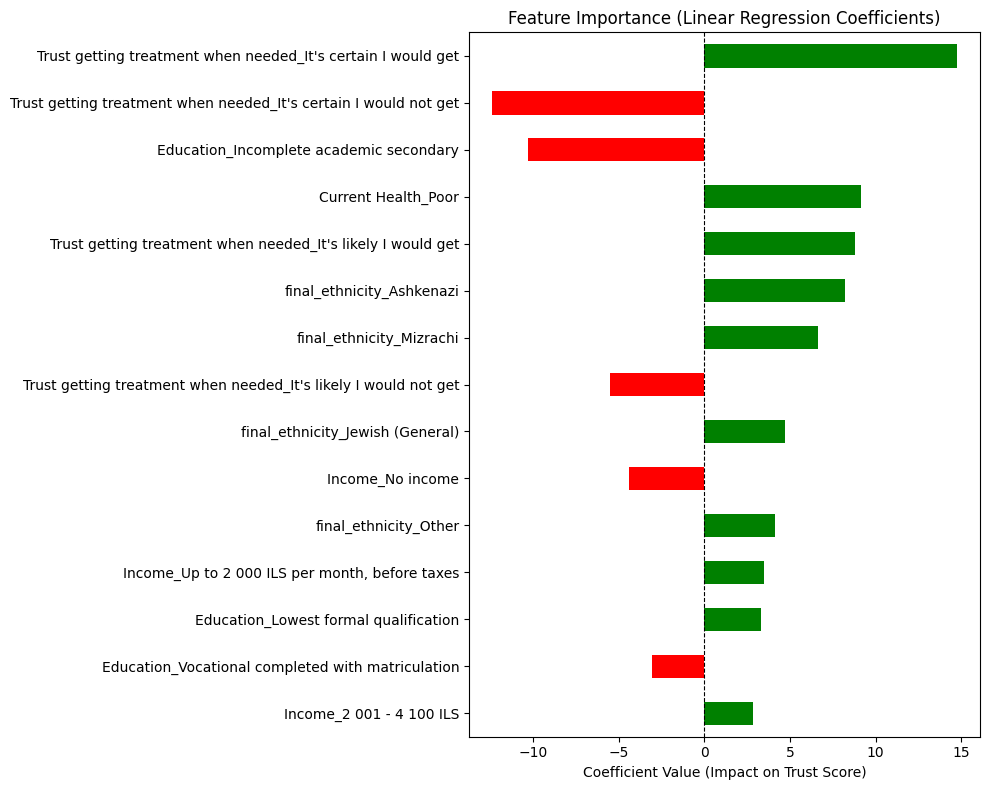

In [83]:
X = pd.get_dummies(df_model[existing_features], drop_first=True)
y = df_model['Trust_Score']

#Compute
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr = LinearRegression()
lr.fit(X_train, y_train)

print(f"Model R-squared: {lr.score(X_test, y_test):.3f}")

#Visualization
coefficients = pd.Series(lr.coef_, index=X.columns)

top_impact_indices = coefficients.abs().nlargest(15).index
top_coefficients = coefficients[top_impact_indices]

# --- MODIFICATION: Rename Labels ---
new_labels = []
for label in top_coefficients.index:
    new_label = str(label)
    # Replace variable codes with descriptive text
    if new_label.startswith('v43'):
        new_label = new_label.replace('v43', 'Trust getting treatment when needed')
    elif new_label.startswith('v51'):
        new_label = new_label.replace('v51', 'Current Health')

    # Optional: Clean up other common prefixes if needed
    new_label = new_label.replace('il_iscd', 'Education').replace('il_rinc', 'Income')

    new_labels.append(new_label)

top_coefficients.index = new_labels
# -----------------------------------

plt.figure(figsize=(10, 8))

#Green for positive value, red for negative value.
colors = ['green' if c > 0 else 'red' for c in top_coefficients]
top_coefficients.plot(kind='barh', color=colors)

plt.title('Feature Importance (Linear Regression Coefficients)')
plt.xlabel('Coefficient Value (Impact on Trust Score)')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

###**(1) Conclusions & Refinement**

**Hypothesis**: Following our analysis in Task 4, that have showed clear gaps of trust in the healthcare system (between ethnicities: Ashkenazi ~60 vs. Arab ~52), we hypothesized that Ethnicity and Socioeconomic Status are the main drivers of trust. We expected that we could predict a persons trust in the healthcare system simply with: Origin, Income, Education

**In reality**: The model achieved a low $R^2$ (~0.174 [or a ~0.42 pearson correlation]). This indicates that Ethnicity and Socioeconomic status have a much lower impact than we have anticipated. **However**, a self-reported health view (v51) had one of the highest impacts on the trust score.

**Interpretation**: Our analysis suggests that Trust may be driven by other/additional factors that we have yet checked. such as Weight, BMI, self-reported health view, gender.

#**Do healthier people trust the healthcare system more/less ?**
#**Could health predict the level of trust in the healthcare system?**

#Health Setup

In [84]:
df_isr['age_clean'] = pd.to_numeric(df_isr['age'], errors='coerce')
df_isr['height_cm'] = pd.to_numeric(df_isr['v53'], errors='coerce')
df_isr['weight_kg'] = pd.to_numeric(df_isr['v54'], errors='coerce')

#The proper way to calc BMI
df_isr['BMI'] = df_isr['weight_kg'] / ((df_isr['height_cm'] / 100) ** 2)

#Expanding our parameters for the Linear Regression
features_to_check = ['v43', 'v51', 'v47_fixed', 'sex', 'il_iscd', 'il_rinc', 'final_ethnicity',
                     'age_clean', 'height_cm', 'weight_kg', 'BMI']

existing_features = [col for col in features_to_check if col in df_isr.columns]

#Cleaning data
df_model = df_isr[existing_features + ['Trust_Score']].copy()
df_model.replace([98, 99, 'Nan', 'nan'], np.nan, inplace=True)

#Filling missing data with median
numeric_cols = ['age_clean', 'height_cm', 'weight_kg', 'BMI']
for col in numeric_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].fillna(df_model[col].median())

if 'il_rinc' in df_model.columns:
    df_model['il_rinc'] = df_model['il_rinc'].fillna(df_model['il_rinc'].mode()[0])

if 'v47_fixed' in df_model.columns:
    df_model['v47_fixed'] = df_model['v47_fixed'].fillna(0)

#Drop rows that we couldn't fill
df_model.dropna(inplace=True)
print(f"\nFinal data for analysis: {len(df_model)} rows")


Final data for analysis: 1088 rows


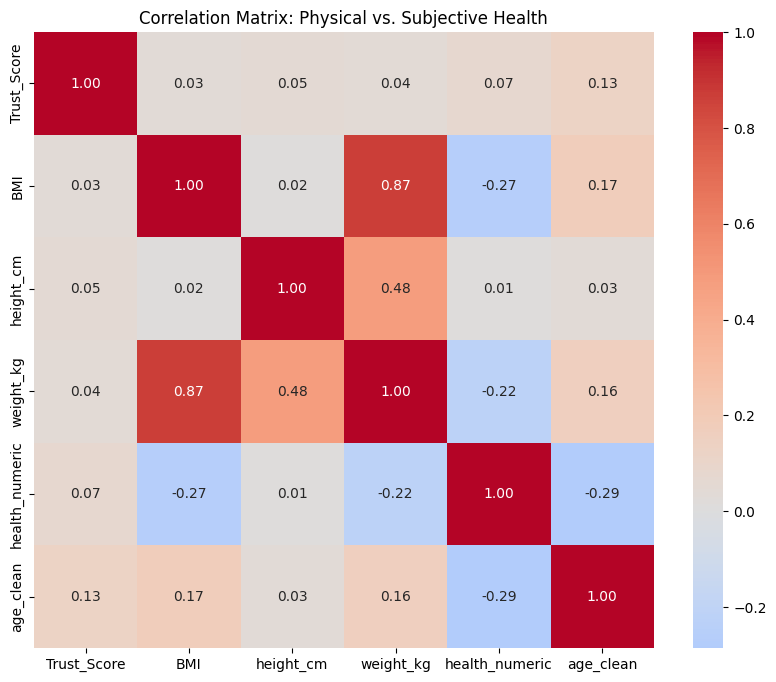


--- Correlation with Trust Score ---
Trust_Score       1.000000
age_clean         0.129796
health_numeric    0.074392
height_cm         0.048918
weight_kg         0.043989
BMI               0.033221
Name: Trust_Score, dtype: float64


In [85]:
#A mapping of self-reported health view.
health_scale = {
    'Poor': 1,
    'Fair': 2,
    'Good': 3,
    'Very good': 4,
    'Excellent': 5
}


#Construct the Visualization (Heathmap) for the Health of those who filled the forms.
df_heatmap_source = df_model.copy()
if 'v51' in df_heatmap_source.columns:
    df_heatmap_source['health_numeric'] = df_heatmap_source['v51'].map(health_scale)

cols_to_check = ['Trust_Score', 'BMI', 'height_cm', 'weight_kg', 'health_numeric', 'age_clean']
cols_to_check = [c for c in cols_to_check if c in df_heatmap_source.columns]

df_heatmap = df_heatmap_source[cols_to_check].dropna()

plt.figure(figsize=(10, 8))
corr_matrix = df_heatmap.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix: Physical vs. Subjective Health')
plt.show()

if 'Trust_Score' in corr_matrix.index:
    print("\n--- Correlation with Trust Score ---")
    print(corr_matrix['Trust_Score'].sort_values(ascending=False))

Interesting to observe:

-Age showed the highest correlation in our health set.


-BMI showed the lowest correlation in our health set.


**And despite that**. "age"'s strongest relationship is with "BMI"

###**(2) Conclusions & Refinement**

**Hypothesis**: Following our low-medium $R^2$ value, and the high impact that ones self-reported health had, we hypothesized that general health could have a higher link to ones view on the healthcare system.

**In reality**: We could not find a strong relationship between ones health and his view on the healthcare system.

**Interpretation**: The question wether a person trusts the healthcare system is perhaps a chaotic one. We need more data.

#**Can we identify a 'Dream Team' of predictors?**
we will now shift to a Data-Driven approach. Instead of manually selecting variables, will scan all available variables and systematically identify the optimal combination of features that maximizes our predictive power, potentially uncovering hidden factors we haven't considered.


--- Results ---
Highest R-squared: 0.182
Selected Features (Best Combination):
["v43_It's certain I would get", "v43_It's certain I would not get", "v43_It's likely I would get", "v43_It's likely I would not get", 'v51_Poor', 'sex_Male', 'il_iscd_Incomplete academic secondary', 'il_iscd_Lowest formal qualification', 'il_iscd_University completed, MA or more', 'il_iscd_Vocational completed with matriculation', 'il_iscd_Vocational completed without matriculation', 'il_rinc_15 101 - 21 500 ILS', 'il_rinc_2 001 - 4 100 ILS', 'il_rinc_5 501 - 6 700 ILS', 'il_rinc_9 501 - 11 700 ILS', 'il_rinc_More than 21 500 ILS per month, before taxes', 'il_rinc_No income', 'il_rinc_Up to 2 000 ILS per month, before taxes', 'final_ethnicity_Ashkenazi', 'final_ethnicity_Jewish (General)', 'final_ethnicity_Mizrachi', 'final_ethnicity_Other']


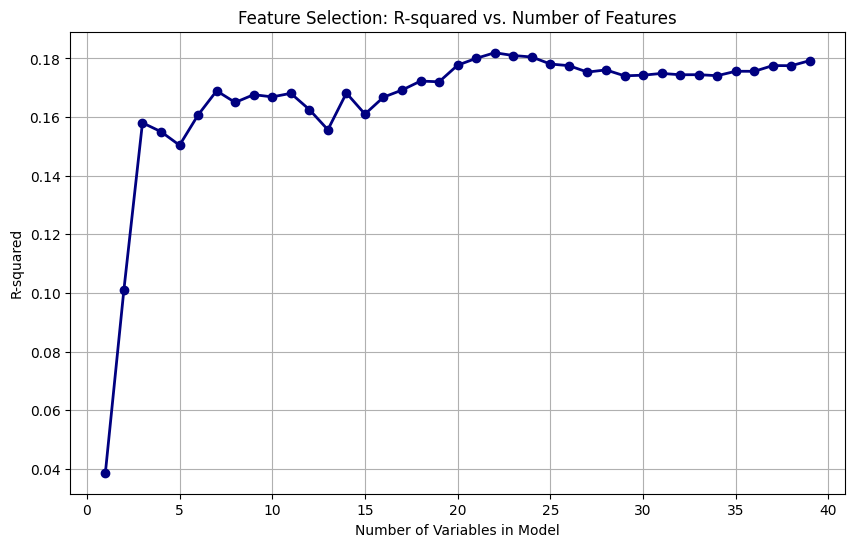

In [86]:
X = pd.get_dummies(df_model[existing_features], drop_first=True)
y = df_model['Trust_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

best_score = -np.inf
best_subset = []
history = []
features_pool = list(X.columns)


#Find top predicators
for k in range(1, len(features_pool) + 1):

    model = LinearRegression()
    selector = RFE(estimator=model, n_features_to_select=k, step=1)
    selector.fit(X_train, y_train)

    #Filter chosen predicators
    current_cols = [f for f, s in zip(features_pool, selector.support_) if s]

    #Train on chosen predicators
    model.fit(X_train[current_cols], y_train)
    score = model.score(X_test[current_cols], y_test)

    history.append({'k': k, 'R2': score})

    if score > best_score:
        best_score = score
        best_subset = current_cols

#Prints
print(f"\n--- Results ---")
print(f"Highest R-squared: {best_score:.3f}")
print("Selected Features (Best Combination):")
print(best_subset)

#Visualization
history_df = pd.DataFrame(history)
plt.figure(figsize=(10, 6))
plt.plot(history_df['k'], history_df['R2'], marker='o', color='navy', linewidth=2)
plt.title('Feature Selection: R-squared vs. Number of Features')
plt.xlabel('Number of Variables in Model')
plt.ylabel('R-squared')
plt.grid(True)
plt.show()

###**(3) Conclusions & Refinement**

**Hypothesis:** Following the limitations of manual selection, we hypothesized that a purely Data-Driven approach would uncover hidden patterns.

**In Reality:** Even with the algorithm's "Dream Team" of variables, we hit a glass ceiling at $R^2 \approx 0.182$.

**Interpretation:** This persistent ceiling suggests that the issue isn't the quality of the data, but rather the heterogeneity of the population. We are trying to force a "one-size-fits-all" formula on the diverse Israeli society.

#Divide and Conquer

In [87]:
model = LinearRegression()

#If a group is too small (50 people or less) we won't check them.
def check_segment(segment_name, condition):
    subset = df_model[condition]
    if len(subset) < 50:
        return

    X_seg = pd.get_dummies(subset[existing_features], drop_first=True)

    valid_cols = [c for c in best_subset if c in X_seg.columns]

    if not valid_cols: return

    X_seg = X_seg[valid_cols]
    y_seg = subset['Trust_Score']

    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_seg, y_seg, test_size=0.2, random_state=42)

    model.fit(X_train_s, y_train_s)
    score = model.score(X_test_s, y_test_s)

    print(f"Segment: {segment_name:<20} | Count: {len(subset):<4} | R-squared: {score:.3f}")

print("--- Analysis by Gender ---")
check_segment("Men", df_model['sex'] == 1)
unique_sex = df_model['sex'].unique()
for s in unique_sex:
    check_segment(f"Sex={s}", df_model['sex'] == s)

print("\n--- Analysis by Ethnicity ---")
unique_eth = df_model['final_ethnicity'].unique()
for e in unique_eth:
    check_segment(f"Ethnicity={e}", df_model['final_ethnicity'] == e)

print("\n--- Analysis by Income Group ---")
unique_inc = df_model['il_rinc'].unique()
for i in unique_inc:
    check_segment(f"Income={i}"[:20], df_model['il_rinc'] == i)

--- Analysis by Gender ---
Segment: Sex=Female           | Count: 581  | R-squared: -0.105
Segment: Sex=Male             | Count: 507  | R-squared: 0.141

--- Analysis by Ethnicity ---
Segment: Ethnicity=Ashkenazi  | Count: 139  | R-squared: 0.213
Segment: Ethnicity=Other      | Count: 356  | R-squared: -0.043
Segment: Ethnicity=Jewish (General) | Count: 358  | R-squared: 0.073
Segment: Ethnicity=Mizrachi   | Count: 142  | R-squared: 0.068
Segment: Ethnicity=Arab       | Count: 93   | R-squared: 0.455

--- Analysis by Income Group ---
Segment: Income=More than 21  | Count: 133  | R-squared: 0.189
Segment: Income=11 701 - 15 1 | Count: 251  | R-squared: 0.056
Segment: Income=2 001 - 4 100 | Count: 80   | R-squared: -0.807
Segment: Income=9 501 - 11 70 | Count: 136  | R-squared: 0.030
Segment: Income=5 501 - 6 700 | Count: 69   | R-squared: 0.033
Segment: Income=15 101 - 21 5 | Count: 109  | R-squared: -0.788
Segment: Income=6 701 - 8 000 | Count: 81   | R-squared: 0.172
Segment: Income=

#**Order vs. Chaos**

**The "Rational" Sector**: The Arab sector yielded an impressive $R^2 \approx 0.455$. This is a major breakthrough. It suggests that trust in this community is highly structured and predictable based on the variables we selected (mainly economic and functional).

**The "Chaotic" Sectors:** On the other end of the spectrum, the model completely collapsed for Low-Income Groups ($R^2 \approx -1.78$) and Women ($R^2 \approx -0.10$).

**The "Ambiguous" Middle:** Groups like Mizrachi Jews ($0.068$) and the General Jewish population ($0.073$) sit in the middle. The model doesn't fail catastrophically, but it also fails to provide any meaningful prediction.

#**Diving Deeper: Decoding the Motives**

(With the focus on ethnic groups)


--- DEEP DIVE: The Arab Sector ---
Analyzing 93 rows from Arab sector...

Top Predictors for Arab:
Education_No formal schooling                                      56.558666
Education_Incomplete university                                    30.042251
Income_4 101 - 5 500 ILS                                           26.982244
Education_Incomplete vocational qualification                      25.801138
Trust getting treatment when needed_It's likely I would not get    24.612481
Education_Vocational completed with matriculation                  21.982314
Education_University completed, BA                                 17.340167
Education_Semi higher, post secondary                              15.322367
dtype: float64


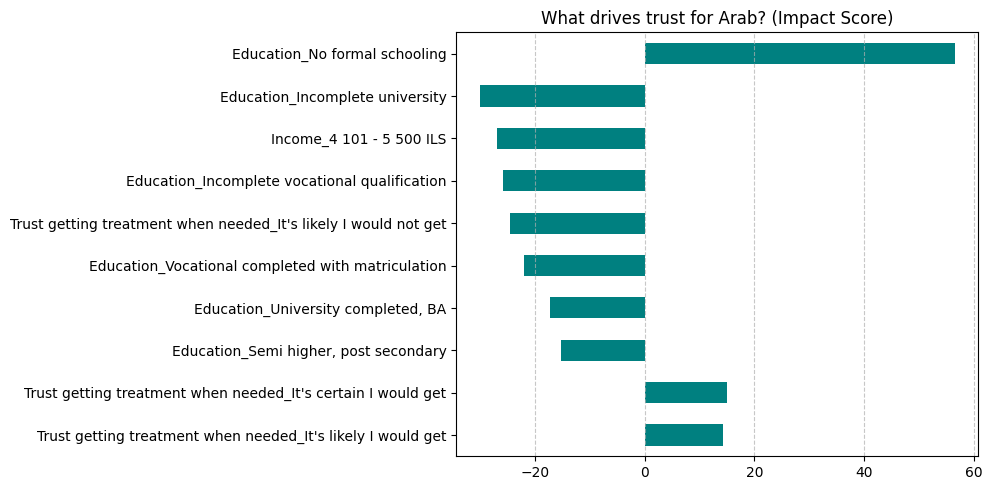


--- DEEP DIVE: The Ashkenazi Sector ---
Analyzing 139 rows from Ashkenazi sector...

Top Predictors for Ashkenazi:
Current Health_Poor                                                57.617100
Income_Up to 2 000 ILS per month, before taxes                     16.991318
Trust getting treatment when needed_It's certain I would get       14.568184
Trust getting treatment when needed_It's likely I would not get    13.829290
Education_Incomplete vocational qualification                      11.947696
Income_No income                                                    9.957459
Education_No formal schooling                                       9.861688
Income_8 001 - 9 500 ILS                                            8.547958
dtype: float64


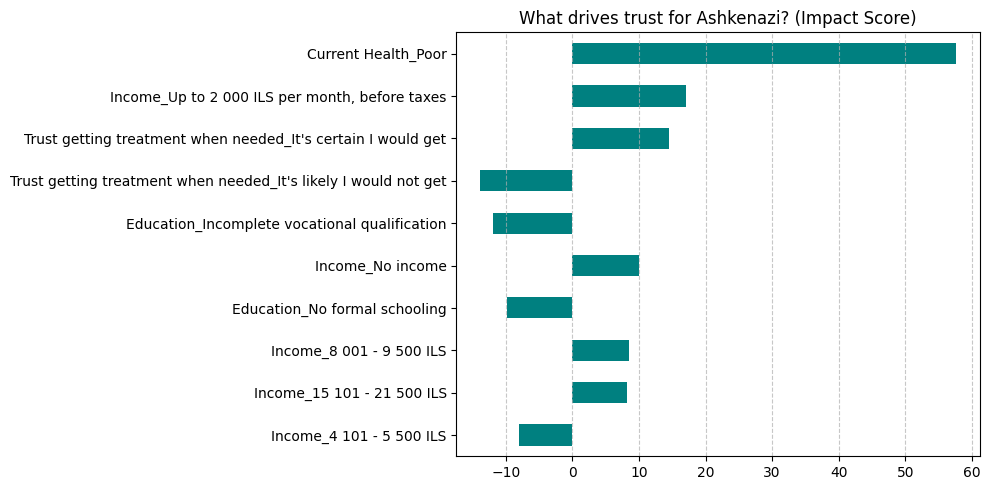


--- DEEP DIVE: The Mizrachi Sector ---
Analyzing 142 rows from Mizrachi sector...

Top Predictors for Mizrachi:
Trust getting treatment when needed_It's certain I would not get                16.628572
Education_Incomplete academic secondary                                         16.286936
Education_Incomplete vocational qualification                                   11.410869
Education_Full general without matriculation + Yeshiva without matriculation    10.483363
Income_2 001 - 4 100 ILS                                                        10.045779
Income_More than 21 500 ILS per month, before taxes                              9.793926
Income_8 001 - 9 500 ILS                                                         8.900499
Income_4 101 - 5 500 ILS                                                         8.594698
dtype: float64


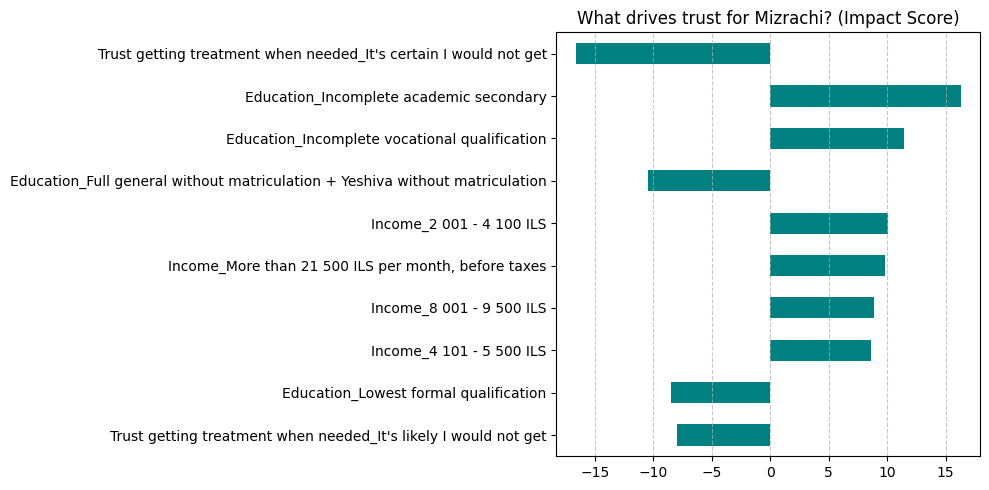

In [88]:
# Define the Rename Mapping
rename_map = {
    'v43': 'Trust getting treatment when needed',
    'v51': 'Current Health',
    'il_iscd': 'Education',
    'il_rinc': 'Income'
}

# Rename columns in the dataframe
df_model = df_model.rename(columns=rename_map)

# Update model_features list to match the new names
old_features = ['v43', 'v51', 'v47_fixed', 'sex', 'il_iscd', 'il_rinc', 'final_ethnicity']
model_features = [rename_map.get(f, f) for f in old_features]

existing_features = [col for col in model_features if col in df_model.columns]

# Prepare the data with dummies
X_all = pd.get_dummies(df_model[existing_features], drop_first=True)
y_all = df_model['Trust_Score']

# Helper function to analyze a specific sector
def analyze_sector(sector_name, filter_condition):
    print(f"\n--- DEEP DIVE: The {sector_name} Sector ---")

    # Filter data for this sector
    subset_indices = df_model[filter_condition].index

    if len(subset_indices) < 10:
        print(f"Not enough data for {sector_name} (n={len(subset_indices)})")
        return

    print(f"Analyzing {len(subset_indices)} rows from {sector_name} sector...")

    X_sector = X_all.loc[subset_indices]
    y_sector = y_all.loc[subset_indices]

    # Remove columns that are constant in this sector (e.g., 'Ethnicity_Arab' will be all 1 or 0)
    X_sector = X_sector.loc[:, (X_sector != X_sector.iloc[0]).any()]

    # Run Regression
    lr = LinearRegression()
    lr.fit(X_sector, y_sector)

    # Extract and print top drivers (Coefficients)
    coef_series = pd.Series(lr.coef_, index=X_sector.columns)

    print(f"\nTop Predictors for {sector_name}:")
    print(coef_series.abs().sort_values(ascending=False).head(8))

    # Visualization
    plt.figure(figsize=(10, 5))

    top_plot = coef_series.iloc[coef_series.abs().argsort()].tail(10)
    top_plot.plot(kind='barh', color='teal')
    plt.title(f'What drives trust for {sector_name}? (Impact Score)')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Analyze Arabs
analyze_sector("Arab", df_model['final_ethnicity'] == 'Arab')

# Analyze Ashkenazim
analyze_sector("Ashkenazi", df_model['final_ethnicity'] == 'Ashkenazi')

# Analyze Mizrahim
analyze_sector("Mizrachi", df_model['final_ethnicity'] == 'Mizrachi')


**==================================================================================**

**The Arab Sector:** "The Socioeconomic Ladder".

**Key Drivers:** Income & Education.

**Insight:** Trust in this sector is highly rational. It strictly follows the socioeconomic ladder: higher status leads to higher trust. If the system "works" for them financially and professionally, they trust it.

**==================================================================================**

**The Ashkenazi Sector:** "The Disappointed Customer".

**Key Driver:** Self-Reported "Poor Health".

**Insight:** Socioeconomic factors matter less here. Instead, trust is performance-based.


**==================================================================================**

**The Mizrachi Sector:** "Institutional Skepticism"

**Key Driver:** Expectation of treatment.

**Insight:** This is the most sensitive group. Trust is not about money (like the Arabs) or health results (like the Ashkenazim), but about Fairness. The strongest predictor of low trust is the deep-seated fear that the system will discriminate against them or ignore them in a time of need.


**==================================================================================**

#**Final Exploration: Changing the Lens**

Throughout this project, we tried to predict the exact Trust Score (Regression) and struggled with high variance. But perhaps we are asking the wrong question. In real life, nuances like "62 vs 65" matter less than the big picture: Does this person trust the system or not?

We will convert our target variable into a Binary Classification:

**High Trust (1) >= 75**

**Low/Medium Trust (0) < 75**


--- Final Explore: The Trust Map (KNN Classification) ---


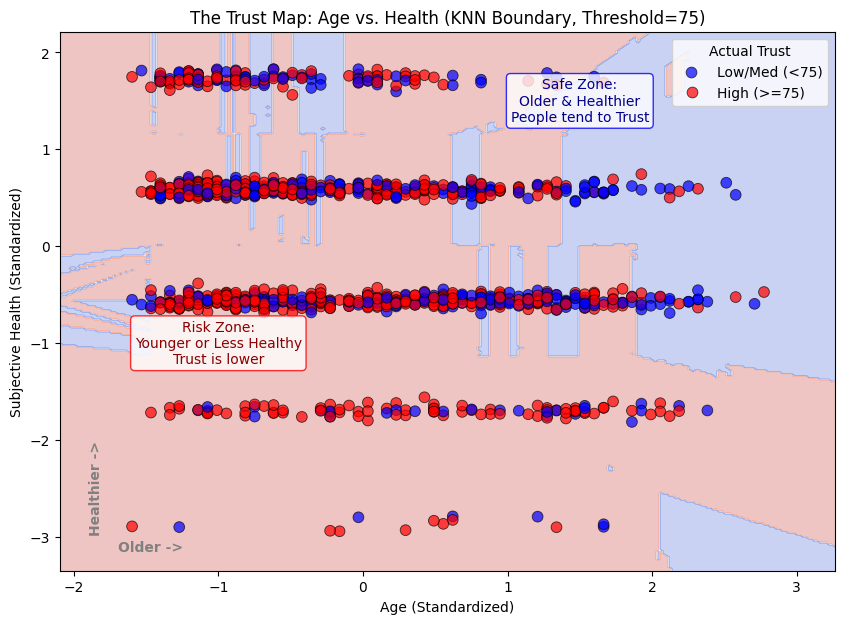

In [89]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

print("\n--- Final Explore: The Trust Map (KNN Classification) ---")

#Set trust in the system threshold
threshold = 75
df_class = df_model.copy()
df_class['Trust_Label'] = (df_class['Trust_Score'] >= threshold).astype(int)

if df_class['Current Health'].dtype == 'O':
    df_class['Health_Num'] = df_class['Current Health'].map(health_scale)
else:
    df_class['Health_Num'] = pd.to_numeric(df_class['v51'], errors='coerce')


plot_data = df_class[['age_clean', 'Health_Num', 'Trust_Label']].dropna()

X_vis = plot_data[['age_clean', 'Health_Num']].values
y_vis = plot_data['Trust_Label'].values

#Train KNN !
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vis)

# K=15 (nearest)
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_scaled, y_vis)

# Visuallization
h = .02
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

#Prediction to each dot
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm_r)
jitter_health = X_scaled[:, 1] + np.random.normal(0, 0.05, size=len(X_scaled))

sns.scatterplot(x=X_scaled[:, 0], y=jitter_health, hue=y_vis,
                palette={0: 'red', 1: 'blue'}, edgecolor='k', s=60, alpha=0.7)

plt.title(f'The Trust Map: Age vs. Health (KNN Boundary, Threshold={threshold})')
plt.xlabel('Age (Standardized)')
plt.ylabel('Subjective Health (Standardized)')
plt.legend(title='Actual Trust', labels=['Low/Med (<75)', 'High (>=75)'], loc='upper right')

# Add Text Annotations to make the zones understandable
# Place text in the "Blue" zone (usually older/healthier)
plt.text(1.5, 1.5, "Safe Zone:\nOlder & Healthier\nPeople tend to Trust",
         horizontalalignment='center', verticalalignment='center',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='blue', boxstyle='round'),
         fontsize=10, color='darkblue')

# Place text in the "Red" zone (usually younger/less healthy)
plt.text(-1.0, -1.0, "Risk Zone:\nYounger or Less Healthy\nTrust is lower",
         horizontalalignment='center', verticalalignment='center',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='red', boxstyle='round'),
         fontsize=10, color='darkred')

plt.text(x_min + 0.2, y_min + 0.4, "Healthier ->", fontsize=10, fontweight='bold', rotation=90, color='gray')
plt.text(x_min + 0.4, y_min + 0.2, "Older ->", fontsize=10, fontweight='bold', color='gray')

plt.grid(False)
plt.show()

#**Conclusion: The Anatomy of Trust**

**The "Glass Ceiling" is Real:** Demographics alone cannot fully explain trust. Personal experiences and cultural values play a massive role that raw data often misses.

**Context Context and again CONTEXT**: By splitting the population, we found order in the chaos. The Arab sector operates on a rational "Socioeconomic Ladder" ($R^2 \approx 0.45$), while other sectors are driven by deeper, perhaps emotional, factors.

**The "Territory of Trust":** Our final map (KNN) reveals the truth: Trust is not randomly distributed. It is a territory occupied largely by the older and healthier population.

**===============================================================================================**

**Final Verdict:**

 To improve trust in the Israeli healthcare system, policymakers cannot rely on general averages. They must address the unique "pain points" of each community—whether it is economic mobility for some, or the assurance of fair treatment for others.

**===============================================================================================**